<a href="https://colab.research.google.com/github/so-rn/Migros-Location-Optimizer/blob/main/Copy_of_Migros_Project_Extension.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## First Project - **MIGROS**

In [48]:
!pip install osmnx geopandas folium statsmodels seaborn

In [49]:
# Import Library
import pandas as pd
import numpy as np
import geopandas as gpd
import osmnx as ox
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import folium

# Set plot style for presentation visuals
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

In [50]:
# DATA LOADING & PRE-PROCESSING (Data Cleaning)
print("Loading and cleaning socio-economic and store datasets...")

# 1.1 Load supermarket data extracted from OpenStreetMap
url = "https://raw.githubusercontent.com/so-rn/Migros-Location-Optimizer/main/Varantorn/1_Get_Data/geneva_supermarkets_data_with_address.csv"
df_stores = pd.read_csv(url)
stores_gdf = gpd.GeoDataFrame(
    df_stores,
    geometry=gpd.points_from_xy(df_stores.longitude, df_stores.latitude),
    crs="EPSG:4326"
)
df_stores.head()

Loading and cleaning socio-economic and store datasets...


,name,brand_category,operator,shop,latitude,longitude,addr:housenumber,addr:street,addr:postcode,addr:city
0,Coop,Coop,NaN,supermarket,46.169006,6.121073,2,Chem. de Vers,1228.0,Plan-les-Ouates
1,Migros,Migros,NaN,supermarket,46.192060,6.164144,86,Route de Florissant,NaN,Genève
2,COOP,Coop,NaN,supermarket,46.193306,6.161276,56,Route de Florissant,1206.0,Genève
3,Migros,Migros,NaN,supermarket,46.190858,6.152480,NaN,NaN,1206.0,NaN
4,Migros,Migros,Société Coopérative Migros Genève,supermarket,46.232767,6.112525,NaN,NaN,NaN,NaN


In [51]:
# Load official population data from Federal Statistical Office (FSO)
url = "https://raw.githubusercontent.com/so-rn/Migros-Location-Optimizer/main/Alexandros%20-%20Population/data/OCS_POPBATLOG_COMMUNE.csv"
df_pop = pd.read_csv(url, sep=';')
df_pop['COMMUNE'] = df_pop['COMMUNE'].str.strip()  # Remove accidental trailing spaces
df_pop.head()

,OBJECTID,DATE_REF,NO_COMMUNE,COMMUNE,BAT_TOTAL,BAT_SANS_LOG,BATLOG_TOT,MAISON_INDIV,BAT_LOG_1_2,BAT_LOG_3_9,...,POPULATION,POP_HOMMES,POP_FEMMES,POP_CH,POP_ETR,AGE_0_19,AGE_20_64,AGE_65_PLUS,SHAPE.AREA,SHAPE.LEN
0,1,12-2025,6624,Gy,265,121,144,96,123,20,...,582,266,316,467,115,137,339,106,3.286289e+06,15240.281691
1,2,12-2025,6631,Onex,2107,795,1312,829,895,164,...,19141,9157,9984,11985,7156,4071,11385,3685,2.813933e+06,8800.054395
2,3,12-2025,6641,Troinex,1309,612,697,522,587,96,...,3365,1667,1698,2573,792,772,2047,546,3.429908e+06,9160.554904
3,20,12-2025,6639,Soral,346,149,197,120,158,37,...,934,436,498,754,180,212,513,209,2.942051e+06,12467.455094
4,21,12-2025,6627,Laconnex,395,189,206,166,196,7,...,713,358,355,610,103,149,401,163,3.831199e+06,9049.018702


In [52]:
# Load purchasing power proxy and filter for the most recent year (2022)
url = "https://raw.githubusercontent.com/so-rn/Migros-Location-Optimizer/main/Varantorn/1_Get_Data/Finance/geneva_purchasing_power_proxy_all_years.csv"
df_power = pd.read_csv(url)
df_power_2022 = df_power[df_power['year'] == 2022].copy()
df_power_2022['commune'] = df_power_2022['commune'].str.strip()
df_power.head()

,year,commune,geography_level,proxy_purchasing_power_median_chf,proxy_index_canton_100,proxy_rank_within_year,all_persons_assujetties,all_q1_chf,all_median_chf,all_q3_chf,...,single_q1_chf,single_median_chf,single_q3_chf,single_q3_q1_ratio,married_persons_assujetties,married_q1_chf,married_median_chf,married_q3_chf,married_q3_q1_ratio,canton_median_chf
0,2014,Canton,canton,59185.00,100.000000,NaN,310208,35313.00,59185.00,93656.0,...,26471.0,52023.5,86761.0,3.277587,150168,42502.75,65122.25,101933.50,2.398280,59185.0
1,2014,Vandoeuvres,commune,93289.50,157.623553,1.0,1769,42609.00,93289.50,205378.5,...,3701.0,45293.0,105307.0,28.453661,1008,72274.50,142530.50,297130.00,4.111132,59185.0
2,2014,Avusy,commune,87582.25,147.980485,2.0,1044,45067.75,87582.25,131921.0,...,15400.5,55726.0,107635.5,6.989091,620,69458.00,101090.50,142510.50,2.051751,59185.0
3,2014,Cologny,commune,87015.00,147.022050,3.0,3452,44344.00,87015.00,169797.0,...,11341.0,61770.5,111505.5,9.832069,1900,64199.00,111992.25,221123.00,3.444337,59185.0
4,2014,Choulex,commune,86205.00,145.653459,4.0,767,47491.00,86205.00,142453.5,...,16009.0,59801.0,117748.0,7.355113,384,68241.50,104701.25,168103.25,2.463358,59185.0


In [53]:
# GEOSPATIAL BOUNDARIES FETCHING & SPATIAL JOIN

print("Fetching administrative commune boundaries for Geneva via OSMnx...")
# Fetch official municipality boundaries (admin_level=8 corresponds to Communes in Switzerland)
geneva_boundaries = ox.features_from_place("Canton of Geneva, Switzerland", tags={'admin_level': '8'})
geneva_boundaries = geneva_boundaries[geneva_boundaries.geometry.type.isin(['Polygon', 'MultiPolygon'])].reset_index()
geneva_boundaries = geneva_boundaries[['name', 'geometry']].rename(columns={'name': 'COMMUNE_NAME'})
geneva_boundaries = geneva_boundaries.to_crs(epsg=4326)

print("Overlaying stores onto boundaries using Spatial Join...")
# Perform a Spatial Join to perfectly assign each store to its true geographical commune boundary
joined_stores = gpd.sjoin(stores_gdf, geneva_boundaries, how="inner", predicate="intersects")
store_counts = joined_stores.groupby('COMMUNE_NAME').size().reset_index(name='STORE_COUNT')

Fetching administrative commune boundaries for Geneva via OSMnx...
Overlaying stores onto boundaries using Spatial Join...


In [54]:
# DATA MERGING & CONSOLIDATION
print("Merging all datasets into a unified master database...")
# Merge geographic data with Population and Purchasing Power data
df_master = geneva_boundaries.merge(df_pop, left_on='COMMUNE_NAME', right_on='COMMUNE', how='left')
df_master = df_master.merge(df_power_2022[['commune', 'proxy_purchasing_power_median_chf']], left_on='COMMUNE_NAME', right_on='commune', how='left')
df_master = df_master.merge(store_counts, on='COMMUNE_NAME', how='left')

# Handle missing values: Communes with no stores should be filled with 0 instead of NaN
df_master['STORE_COUNT'] = df_master['STORE_COUNT'].fillna(0)

# Calculate structural socio-demographic ratios for comparative evaluation
df_master['PCT_WORKING_AGE'] = (df_master['AGE_20_64'] / df_master['POPULATION']) * 100
df_master['PCT_SINGLE_FAMILY'] = (df_master['MAISON_INDIV'] / df_master['BATLOG_TOT']) * 100
df_master['PCT_FOREIGNERS'] = (df_master['POP_ETR'] / df_master['POPULATION']) * 100

# Remove any null rows across main model features
df_clean = df_master.dropna(subset=['POPULATION', 'proxy_purchasing_power_median_chf']).copy()
df_clean = df_clean[df_clean['COMMUNE_NAME'] != 'Genève']

Merging all datasets into a unified master database...


In [61]:
# MULTIPLE LINEAR REGRESSION RUN (OLS MODEL)
print("\nScreening for extreme statistical outliers using Cook's Distance...")
X_initial = sm.add_constant(df_clean[['POPULATION', 'proxy_purchasing_power_median_chf']])
y_initial = df_clean['STORE_COUNT']
initial_model = sm.OLS(y_initial, X_initial).fit()

# Calculate leverage/influence thresholds
influence = initial_model.get_influence()
cooks_distances = influence.cooks_distance[0]
df_clean['COOKS_D'] = cooks_distances

# Set threshold boundary (Standard formula: 4 / total number of observations)
cooks_threshold = 4 / len(df_clean)
outliers = df_clean[df_clean['COOKS_D'] > cooks_threshold]

print(f"-> Mapped out {len(outliers)} highly skewed outliers (e.g., Genève City center).")
# Filter out identified outliers to focus on suburban expansion areas
df_filtered = df_clean[df_clean['COOKS_D'] <= cooks_threshold].copy()


Screening for extreme statistical outliers using Cook's Distance...
-> Mapped out 4 highly skewed outliers (e.g., Genève City center).


Plotting Data Distribution (Histograms & KDE)...


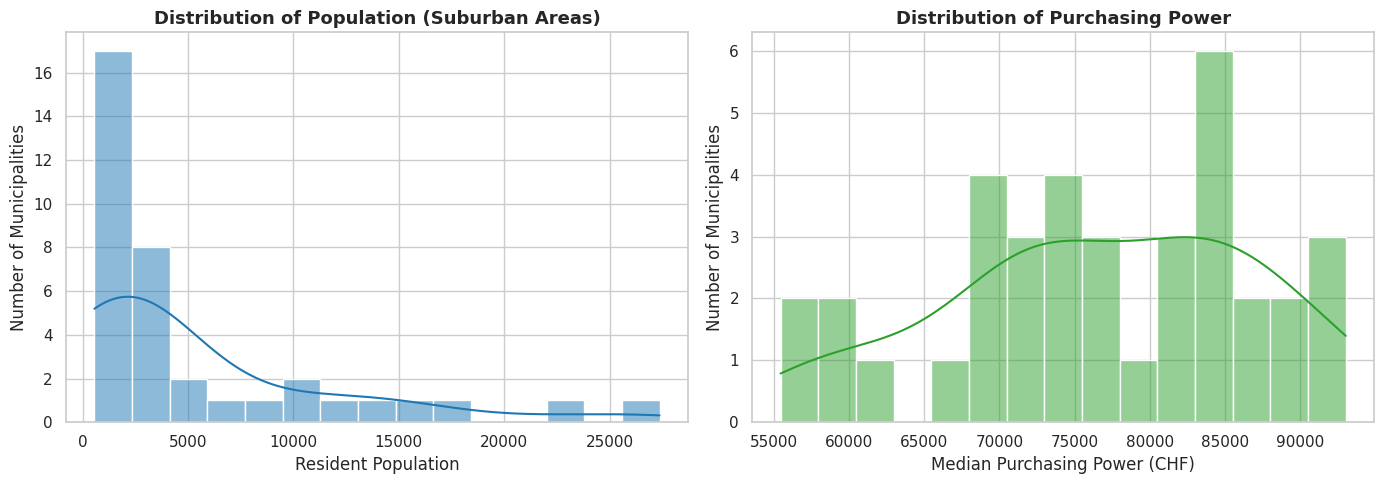

In [62]:
# DATA DISTRIBUTION VISUALIZATION
print("Plotting Data Distribution (Histograms & KDE)...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Distribution of Population
sns.histplot(df_filtered['POPULATION'], bins=15, kde=True, color='#1f77b4', ax=axes[0])
axes[0].set_title('Distribution of Population (Suburban Areas)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Resident Population')
axes[0].set_ylabel('Number of Municipalities')

# Right : Distribution of Purchasing Power
sns.histplot(df_filtered['proxy_purchasing_power_median_chf'], bins=15, kde=True, color='#2ca02c', ax=axes[1])
axes[1].set_title('Distribution of Purchasing Power', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Median Purchasing Power (CHF)')
axes[1].set_ylabel('Number of Municipalities')

plt.tight_layout()
plt.savefig('Migros_Data_Distribution.png', dpi=300)
plt.show()

In [56]:
print("\nExecuting robust OLS Linear Regression on filtered data...")
X_final = sm.add_constant(df_filtered[['POPULATION', 'proxy_purchasing_power_median_chf']])
y_final = df_filtered['STORE_COUNT']

final_model = sm.OLS(y_final, X_final).fit()
print(final_model.summary())

# Calculate expected store equilibrium and find under-served markets
df_filtered['PREDICTED_STORES'] = final_model.predict(X_final)
df_filtered['OPPORTUNITY_SCORE'] = df_filtered['PREDICTED_STORES'] - df_filtered['STORE_COUNT']

# Isolate top investment locations
top_locations = df_filtered.sort_values(by='OPPORTUNITY_SCORE', ascending=False).head(5)
print("\n🔥 TOP 5 SUBURBAN OPPORTUNITIES FOR NEW MIGROS OUTLETS (Outliers Removed):")
print(top_locations[['COMMUNE_NAME', 'POPULATION', 'STORE_COUNT', 'PREDICTED_STORES', 'OPPORTUNITY_SCORE']])


Executing robust OLS Linear Regression on filtered data...
                            OLS Regression Results                            
Dep. Variable:            STORE_COUNT   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.888
Method:                 Least Squares   F-statistic:                     143.4
Date:                Thu, 21 May 2026   Prob (F-statistic):           2.69e-17
Time:                        15:28:40   Log-Likelihood:                -38.019
No. Observations:                  37   AIC:                             82.04
Df Residuals:                      34   BIC:                             86.87
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------

In [57]:
import statsmodels.api as sm

# Create a function to calculate R-Squared for each feature individually
def print_rsquared(feature_name, df):
    # Prepare X and y data
    X = sm.add_constant(df[feature_name])
    y = df['STORE_COUNT']

    # Fit the OLS model
    model = sm.OLS(y, X).fit()

    # Extract the R-Squared value and convert it to a percentage
    r2_percent = model.rsquared * 100

    # Print the result
    print(f"👉 R-Squared of {feature_name:<20} = {r2_percent:>5.2f}%")

print("--- R-Squared Comparison (Store Count Prediction Accuracy) ---")

print_rsquared('POPULATION', df_filtered)
print_rsquared('PCT_WORKING_AGE', df_filtered)
print_rsquared('PCT_SINGLE_FAMILY', df_filtered)
print_rsquared('PCT_FOREIGNERS', df_filtered)
print_rsquared('proxy_purchasing_power_median_chf', df_filtered)

--- R-Squared Comparison (Store Count Prediction Accuracy) ---
👉 R-Squared of POPULATION           = 88.48%
👉 R-Squared of PCT_WORKING_AGE      = 19.06%
👉 R-Squared of PCT_SINGLE_FAMILY    = 13.10%
👉 R-Squared of PCT_FOREIGNERS       = 27.36%
👉 R-Squared of proxy_purchasing_power_median_chf = 41.61%



Plotting comparative multi-aspect visualization dashboard...


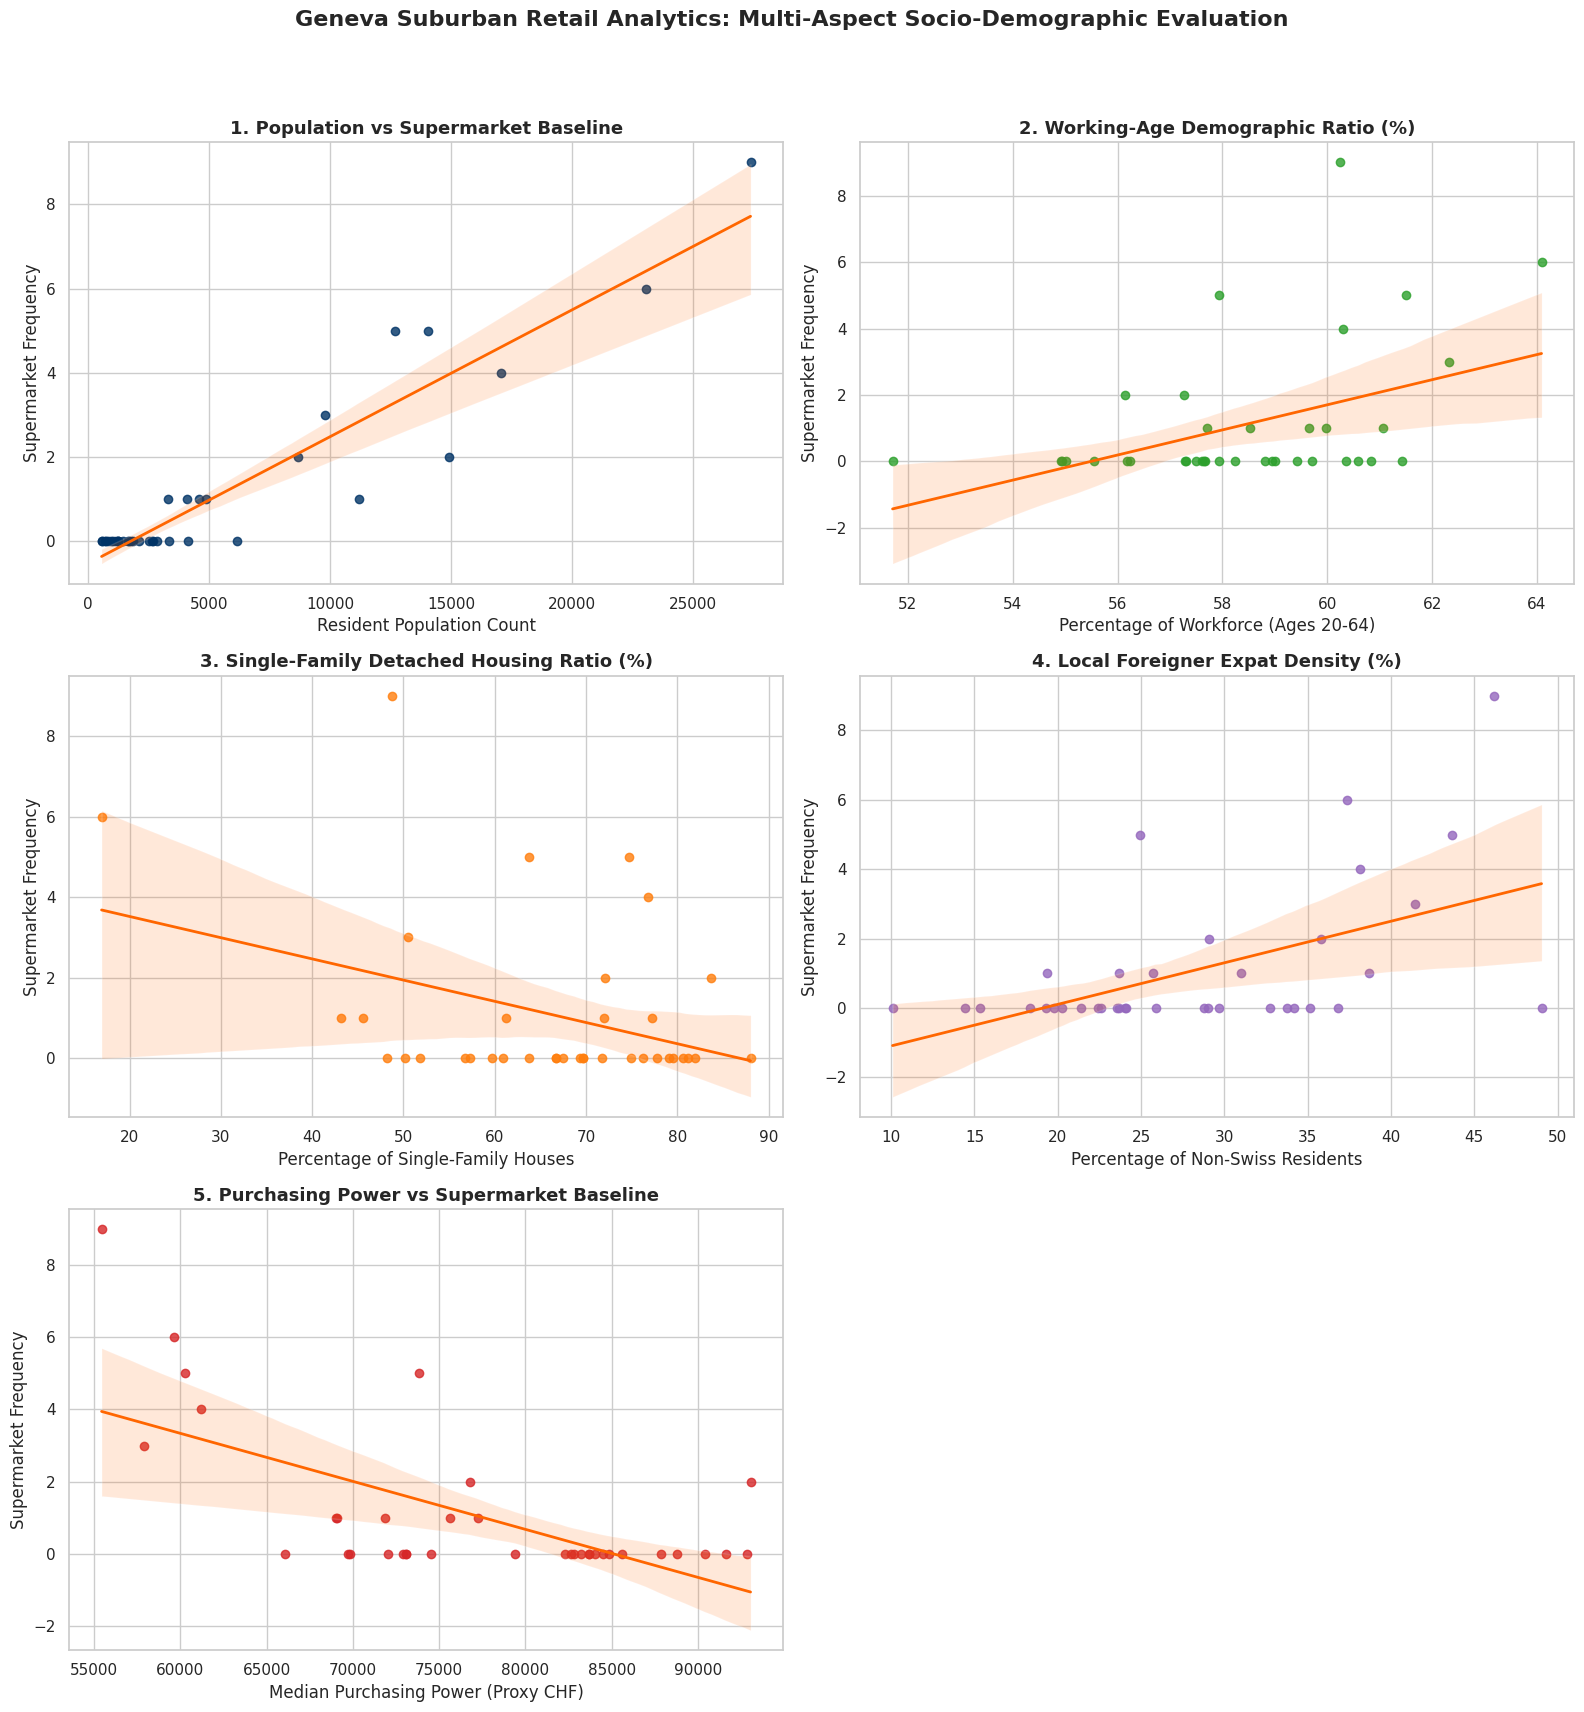

In [58]:
# ==============================================================================
# DEMOGRAPHIC COMPARISON VISUALIZATIONS (DASHBOARD)
# ==============================================================================
print("\nPlotting comparative multi-aspect visualization dashboard...")
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Subplot 1: Clean Population Baseline
sns.regplot(ax=axes[0, 0], x='POPULATION', y='STORE_COUNT', data=df_filtered, color='#003366', line_kws={'color': '#FF6600', 'lw': 2})
axes[0, 0].set_title('1. Population vs Supermarket Baseline', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Resident Population Count')
axes[0, 0].set_ylabel('Supermarket Frequency')

# Subplot 2: Age Structural Density
sns.regplot(ax=axes[0, 1], x='PCT_WORKING_AGE', y='STORE_COUNT', data=df_filtered, color='#2ca02c', line_kws={'color': '#FF6600', 'lw': 2})
axes[0, 1].set_title('2. Working-Age Demographic Ratio (%)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Percentage of Workforce (Ages 20-64)')
axes[0, 1].set_ylabel('Supermarket Frequency')

# Subplot 3: Urban vs Suburban Housing Footprints
sns.regplot(ax=axes[1, 0], x='PCT_SINGLE_FAMILY', y='STORE_COUNT', data=df_filtered, color='#ff7f0e', line_kws={'color': '#FF6600', 'lw': 2})
axes[1, 1].set_ylabel('Supermarket Frequency') # Fix the Y-axis label that was misplaced in the original file
axes[1, 0].set_title('3. Single-Family Detached Housing Ratio (%)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Percentage of Single-Family Houses')
axes[1, 0].set_ylabel('Supermarket Frequency')

# Subplot 4: Cosmopolitan Foreigner Influx
sns.regplot(ax=axes[1, 1], x='PCT_FOREIGNERS', y='STORE_COUNT', data=df_filtered, color='#9467bd', line_kws={'color': '#FF6600', 'lw': 2})
axes[1, 1].set_title('4. Local Foreigner Expat Density (%)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Percentage of Non-Swiss Residents')
axes[1, 1].set_ylabel('Supermarket Frequency')

# Subplot 5: Purchasing Power Impact (Newly added as requested)
sns.regplot(ax=axes[2, 0], x='proxy_purchasing_power_median_chf', y='STORE_COUNT', data=df_filtered, color='#d62728', line_kws={'color': '#FF6600', 'lw': 2})
axes[2, 0].set_title('5. Purchasing Power vs Supermarket Baseline', fontsize=13, fontweight='bold')
axes[2, 0].set_xlabel('Median Purchasing Power (Proxy CHF)')
axes[2, 0].set_ylabel('Supermarket Frequency')

# Hide the empty subplot at [2, 1] for a cleaner presentation (avoiding a blank box)
axes[2, 1].axis('off')

# Adjust the overall layout to be balanced and save the figure
plt.suptitle('Geneva Suburban Retail Analytics: Multi-Aspect Socio-Demographic Evaluation', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('Geneva_Cleaned_Market_Dashboard.png', dpi=300)
plt.show()

In [59]:
print("Constructing interactive geospatial market opportunity map...")
map_center_lat = geneva_boundaries.geometry.centroid.y.mean()
map_center_lon = geneva_boundaries.geometry.centroid.x.mean()
geomap = folium.Map(location=[map_center_lat, map_center_lon], zoom_start=11.5, tiles="cartodbpositron")

# Generate the colored choropleth layers
heat_layer = folium.Choropleth(
    geo_data=geneva_boundaries,
    name="Filtered Market Gaps",
    data=df_filtered,
    columns=["COMMUNE_NAME", "OPPORTUNITY_SCORE"],
    key_on="feature.properties.COMMUNE_NAME",
    fill_color="YlGnBu",
    fill_opacity=0.7,
    line_opacity=0.4,
    legend_name="Strategic Opportunity Index (Higher Values indicate Severe Supply Gaps)",
    nan_fill_color="#DDDDDD"
)

# Inject hovering descriptive metadata tags
heat_layer.geojson.add_child(
    folium.features.GeoJsonTooltip(
        fields=['COMMUNE_NAME'],
        aliases=['Municipality:'],
        labels=True
    )
)
heat_layer.add_to(geomap)

# Drop localized physical landmark pins
for idx, row in joined_stores.iterrows():
    if row['COMMUNE_NAME'] in df_filtered['COMMUNE_NAME'].values:
        brand_color = 'red' if row['brand_category'] == 'Coop' else 'orange' if row['brand_category'] == 'Migros' else 'blue'

        info_bubble = f"""
        <div style='font-family: Arial, sans-serif; font-size:12px; width: 180px;'>
            <b style='color:#E65100; font-size:13px;'>{row['brand_category']}</b><br>
            <b>Type:</b> {row['shop']}<br>
            <b>District:</b> {row['COMMUNE_NAME']}
        </div>
        """
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=4,
            popup=folium.Popup(info_bubble, max_width=220),
            color=brand_color,
            fill=True,
            fill_opacity=0.8
        ).add_to(geomap)

geomap.save('Migros_Suburban_Expansion_Map.html')
print("Process Completed Successfully! Map file saved as 'Migros_Suburban_Expansion_Map.html'")

# Display directly inside the Jupyter interface
geomap

Constructing interactive geospatial market opportunity map...
Process Completed Successfully! Map file saved as 'Migros_Suburban_Expansion_Map.html'


In [60]:
# This is show if we plot all possible area include Geneva are will hard to see

import folium
from folium.plugins import DualMap
from IPython.display import display, HTML
import statsmodels.api as sm

# Prepare "Original" data (Create a temporary table to drop NaN values but keep Genève)
df_temp_orig = df_master.dropna(subset=['POPULATION', 'proxy_purchasing_power_median_chf']).copy()

X_orig = sm.add_constant(df_temp_orig[['POPULATION', 'proxy_purchasing_power_median_chf']])
y_orig = df_temp_orig['STORE_COUNT']
model_orig = sm.OLS(y_orig, X_orig).fit()

# Calculate the original opportunity score (where the scale is skewed due to the large city)
df_temp_orig['OPP_SCORE_ORIGINAL'] = model_orig.predict(X_orig) - df_temp_orig['STORE_COUNT']

# Set the center coordinates and create the DualMap
map_center = [geneva_boundaries.geometry.centroid.y.mean(), geneva_boundaries.geometry.centroid.x.mean()]
dual_map = DualMap(location=map_center, zoom_start=12, tiles="cartodbpositron")

# Left Side (m1): Original View (Full data including Genève / Color scale skewed by the large city)

folium.Choropleth(
    geo_data=geneva_boundaries,          # Draw boundaries for all municipalities
    name="1. Original (Full Data)",
    data=df_temp_orig,                   # <--- Fix: Use the temporary table without NaNs
    columns=["COMMUNE_NAME", "OPP_SCORE_ORIGINAL"],
    key_on="feature.properties.COMMUNE_NAME",
    fill_color="YlGnBu",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Uncleaned Opp. Score (Baseline)",
    nan_fill_color="white"               # 3 districts with missing data will be left white
).add_to(dual_map.m1)

# Right Side (m2): Advanced Suburban View (Outliers removed / Gray shading)
folium.Choropleth(
    geo_data=geneva_boundaries,          # Draw boundaries for all municipalities
    name="2. Advanced (Suburban Focus)",
    data=df_filtered,                    # Cleaned data with outliers removed
    columns=["COMMUNE_NAME", "OPPORTUNITY_SCORE"],
    key_on="feature.properties.COMMUNE_NAME",
    fill_color="YlGnBu",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Cleaned Opp. Score (Suburban Focus)",
    nan_fill_color="#CCCCCC"             # <--- Removed outliers like Genève will clearly become gray
).add_to(dual_map.m2)

# Place Store Markers on both sides (to show actual coordinates)
for _, row in joined_stores.iterrows():
    b_color = 'red' if row['brand_category'] == 'Coop' else 'orange' if row['brand_category'] == 'Migros' else 'blue'

    # Left side markers
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']], radius=3,
        color=b_color, fill=True, fill_opacity=0.8
    ).add_to(dual_map.m1)

    # Right side markers
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']], radius=3,
        color=b_color, fill=True, fill_opacity=0.8
    ).add_to(dual_map.m2)

# Save and Display
dual_map.save('Migros_Final_Comparison.html')
print("Comparison complete! The right map shows clearer opportunities in the suburbs.")
display(HTML(dual_map._repr_html_()))

Comparison complete! The right map shows clearer opportunities in the suburbs.


Plotting Correlation Heatmap...


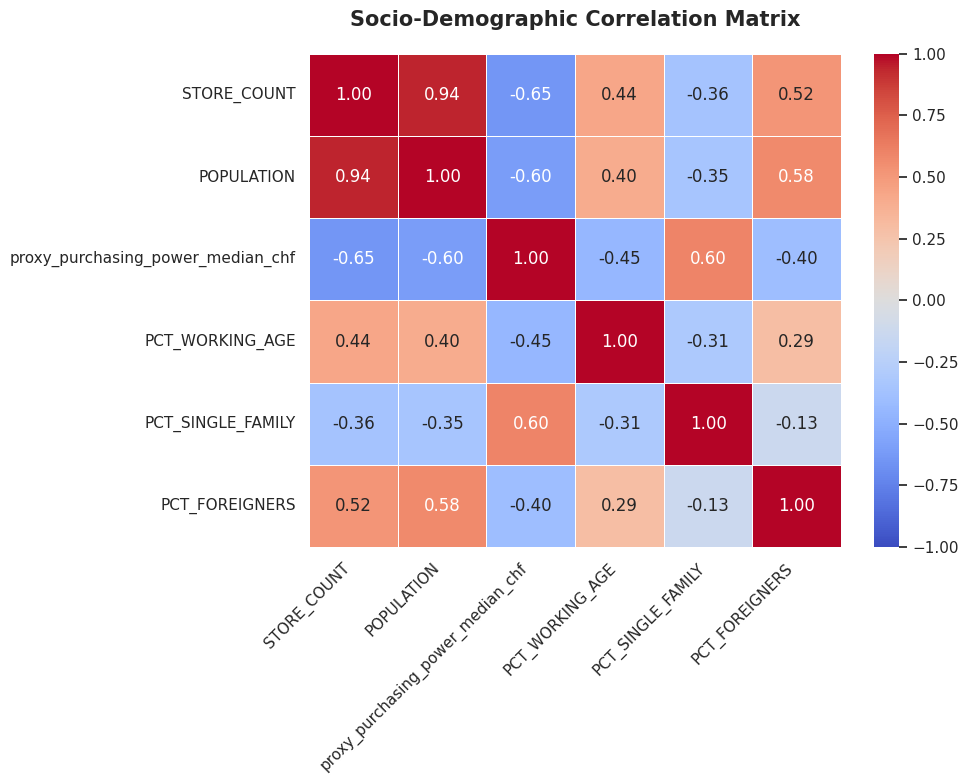

In [64]:
# CORRELATION MATRIX HEATMAP

print("Plotting Correlation Heatmap...")

plt.figure(figsize=(10, 8))


cols_to_check = [
    'STORE_COUNT', 'POPULATION', 'proxy_purchasing_power_median_chf',
    'PCT_WORKING_AGE', 'PCT_SINGLE_FAMILY', 'PCT_FOREIGNERS'
]


corr_matrix = df_filtered[cols_to_check].corr()


sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1
)

plt.title('Socio-Demographic Correlation Matrix', fontsize=15, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('Migros_Correlation_Heatmap.png', dpi=300)
plt.show()